In [47]:
#! pip install torchsummary
#! pip install pytorch-ignite

In [48]:
# Installa PyTorch con supporto MPS
#! pip install torch torchvision torchaudio

In [49]:
#! pip install --upgrade pip

In [50]:
#from google.colab import drive

# Monta Google Drive
#drive.mount('/content/drive')

NN Pytorch

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torchsummary import summary
from torch.nn.init import xavier_normal_
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

In [52]:
from sklearn.model_selection import KFold, train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

In [53]:
from ignite.metrics import Accuracy, Loss
from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator

In [54]:
import torch

print("CUDA disponibile:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nome GPU:", torch.cuda.get_device_name(0))
    print("Numero dispositivi:", torch.cuda.device_count())
    print("Device corrente:", torch.cuda.current_device())


CUDA disponibile: False


In [55]:
x_train = (pd.read_csv('/content/drive/MyDrive/X_train_rating_no_out.csv')).drop('Unnamed: 0', axis =1)
y_train = (pd.read_csv('/content/drive/MyDrive/y_train_rating_no_out.csv')).drop('Unnamed: 0', axis =1)

x_test = (pd.read_csv('/content/drive/MyDrive/X_test_rating.csv')).drop('Unnamed: 0', axis =1)
y_test = pd.read_csv('/content/drive/MyDrive/y_test_rating.csv')

In [56]:
y_train = y_train['rating']
y_test = y_test['rating']

In [57]:
# log transformation delle seguenti colonne: runtimeminutes, numvotes, totalcredits, userrewtotal, totalmedia
cols = ['runtimeMinutes', 'numVotes', 'totalCredits', 'userReviewsTotal', 'totalMedia']

for col in cols:
    x_train[col] = np.log1p(x_train[col])
    x_test[col] = np.log1p(x_test[col])

In [58]:
scaler = StandardScaler()

num_cols = ['startYear', 'runtimeMinutes', 'numVotes', 'totalCredits', 'criticReviewsTotal', 'numRegions', 'userReviewsTotal',
        'companiesNumber', 'externalLinks', 'writerCredits',
        'directorsCredits', 'quotesTotal', 'totalMedia', 'totalNominations']

scaler.fit(x_train[num_cols])

StandardScaler()

In [59]:
x_train[num_cols] = scaler.transform(x_train[num_cols])
x_test[num_cols] = scaler.transform(x_test[num_cols])

## Costruzione rete

In [60]:
x_train_split, x_val, y_train_split, y_val = train_test_split(x_train, y_train, test_size=0.3, random_state=42)

In [61]:
y_train_split = y_train_split-1
y_val = y_val-1
y_test = y_test -1

In [62]:
x_train_tensor = torch.tensor(x_train_split.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_split.values, dtype=torch.long)

x_val_tensor = torch.tensor(x_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.to_numpy(), dtype=torch.long)

x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

In [63]:
# Conta quanti esempi ci sono per ogni classe
class_counts = torch.bincount(y_train_tensor)
class_weights = 1.0 / class_counts.float()

# Assegna a ciascun campione il peso della sua classe
sample_weights = class_weights[y_train_tensor]

# Crea il sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  # numero di campioni da estrarre per epoch
    replacement=True
)

In [64]:
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

In [65]:
train_loader = DataLoader(train_dataset, batch_size=32, sampler = sampler)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in uso:", device)

Device in uso: cpu


In [67]:
class NNClassifier(nn.Module):

    def __init__(self, input_dim, hidden_size1, hidden_size2, hidden_size3, hidden_size4, output_size):
        super(NNClassifier, self).__init__()

        self.input_layer = nn.Linear(input_dim, hidden_size1)
        self.hidden_layer1 = nn.Linear(hidden_size1, hidden_size2)
        self.hidden_layer2 = nn.Linear(hidden_size2, hidden_size3)
        self.hidden_layer3 = nn.Linear(hidden_size3, hidden_size4)
        self.output_layer = nn.Linear(hidden_size4, output_size)

        self.tanh = nn.ReLU()
        self.dropout = nn.Dropout(p = 0.4)

    # Applicazione delle funzioni di attivazione per ogni strato
    def forward(self, x):
        x = self.tanh(self.input_layer(x))
        x = self.dropout(x)
        x = self.tanh(self.hidden_layer1(x))
        x = self.dropout(x)
        x = self.tanh(self.hidden_layer2(x))
        x = self.dropout(x)
        x = self.tanh(self.hidden_layer3(x))
        x = self.dropout(x)
        x = self.output_layer(x)

        return x


In [68]:
n_classes = len(np.unique(y_train))
input_size = x_train.shape[1]
hidden_size1 = 512
hidden_size2 = 256
hidden_size3 = 128
hidden_size4 = 128
output_size = n_classes

In [69]:
from ignite.handlers import EarlyStopping, ModelCheckpoint
from ignite.contrib.handlers import global_step_from_engine
from ignite.engine import Engine, Events, create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import  Precision, Recall, Fbeta

In [70]:
precision = Precision(average=True)
recall = Recall(average=True)
f1_macro = Fbeta(beta=1.0, average=True)

In [71]:
model = NNClassifier(input_size, hidden_size1, hidden_size2, hidden_size3, hidden_size4, output_size)
model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay = 1e-4)
criterion = nn.CrossEntropyLoss()

In [72]:
trainer = create_supervised_trainer(model, optimizer, criterion, device)

In [73]:
val_metrics = {
    "accuracy": Accuracy(device = device),
    "loss": Loss(criterion, device=device),  # qui passa la loss function che usi
    "f1_macro": Fbeta(beta=1.0, average=True, device=device)
}

# ignite train and validation evaluators
train_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)
val_evaluator = create_supervised_evaluator(model, metrics=val_metrics, device=device)

training_history = {'accuracy':[],'loss':[], 'f1_macro':[]}
validation_history = {'accuracy':[],'loss':[], 'f1_macro':[]}

In [74]:
log_interval = 100

@trainer.on(Events.ITERATION_COMPLETED(every=log_interval))
def log_training_loss(engine):
    print(f"Epoch[{engine.state.epoch}], Iter[{engine.state.iteration}] Loss: {engine.state.output:.2f}")

# after a training epoch, computes training and validation metrics (train_eval on train_loader and val_eval on val_loader)
@trainer.on(Events.EPOCH_COMPLETED)
def log_training_results(trainer):
    train_evaluator.run(train_loader)
    metrics = train_evaluator.state.metrics
    training_history['accuracy'].append(metrics['accuracy']*100)
    training_history['loss'].append(metrics['loss'])
    training_history['f1_macro'].append(metrics['f1_macro'])
    print(f"Training Results - Epoch[{trainer.state.epoch}] Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['loss']:.2f}, Avg f1: {metrics['f1_macro']:.2f}")

@trainer.on(Events.EPOCH_COMPLETED)
def log_validation_results(trainer):
    val_evaluator.run(val_loader)
    metrics = val_evaluator.state.metrics
    validation_history['accuracy'].append(metrics['accuracy']*100)
    validation_history['loss'].append(metrics['loss'])
    validation_history['f1_macro'].append(metrics['f1_macro'])
    print(f"Validation Results - Epoch[{trainer.state.epoch}] Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['loss']:.2f} Avg f1: {metrics['f1_macro']:2f}")

In [75]:
def score_function(engine):
    return engine.state.metrics["f1_macro"]

In [76]:
handler = EarlyStopping(patience=50, score_function=score_function, trainer=trainer)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

# Per ReduceLROnPlateau devi gestire lo scheduler manualmente
# perché ha bisogno di una metrica per decidere quando ridurre il LR
@val_evaluator.on(Events.EPOCH_COMPLETED)
def scheduler_step(engine):
    # Ottieni la loss di validazione dalle metriche
    val_loss = engine.state.metrics['loss']
    scheduler.step(val_loss)

@trainer.on(Events.EPOCH_COMPLETED)
def print_lr(engine):
    print("Learning Rate:", optimizer.param_groups[0]['lr'])

checkpoint = ModelCheckpoint(
    dirname='models',
    filename_prefix='best_EARLY',
    n_saved=1,
    create_dir=True,
    global_step_transform=global_step_from_engine(trainer)
)

val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, handler)
val_evaluator.add_event_handler(Events.EPOCH_COMPLETED, checkpoint, {'model': model})

In [77]:
trainer.run(train_loader, max_epochs=200)

Epoch[1], Iter[100] Loss: 2.21
Epoch[1], Iter[200] Loss: 2.49
Epoch[1], Iter[300] Loss: 2.10
Epoch[1], Iter[400] Loss: 2.09
Epoch[1], Iter[500] Loss: 2.23
Epoch[1], Iter[600] Loss: 2.16
Epoch[1], Iter[700] Loss: 2.19
Epoch[1], Iter[800] Loss: 2.07
Epoch[1], Iter[900] Loss: 2.20
Epoch[1], Iter[1000] Loss: 2.39
Epoch[1], Iter[1100] Loss: 2.23
Epoch[1], Iter[1200] Loss: 2.29
Epoch[1], Iter[1300] Loss: 2.19
Epoch[1], Iter[1400] Loss: 2.21
Epoch[1], Iter[1500] Loss: 2.13
Epoch[1], Iter[1600] Loss: 2.16
Epoch[1], Iter[1700] Loss: 2.20
Epoch[1], Iter[1800] Loss: 2.29
Epoch[1], Iter[1900] Loss: 2.32
Epoch[1], Iter[2000] Loss: 2.16
Epoch[1], Iter[2100] Loss: 2.16
Epoch[1], Iter[2200] Loss: 2.12
Training Results - Epoch[1] Avg accuracy: 0.19 Avg loss: 2.17, Avg f1: 0.09
Validation Results - Epoch[1] Avg accuracy: 0.21 Avg loss: 2.13 Avg f1: 0.077240
Learning Rate: 0.01
Epoch[2], Iter[2300] Loss: 2.26
Epoch[2], Iter[2400] Loss: 2.06
Epoch[2], Iter[2500] Loss: 2.15
Epoch[2], Iter[2600] Loss: 2.33


2025-08-26 07:45:12,997 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


Validation Results - Epoch[145] Avg accuracy: 0.31 Avg loss: 1.62 Avg f1: 0.236857
Learning Rate: 1.52587890625e-07


State:
	iteration: 322625
	epoch: 145
	epoch_length: 2225
	max_epochs: 200
	output: 0.8810664415359497
	batch: <class 'list'>
	metrics: <class 'dict'>
	dataloader: <class 'torch.utils.data.dataloader.DataLoader'>
	seed: <class 'NoneType'>
	times: <class 'dict'>

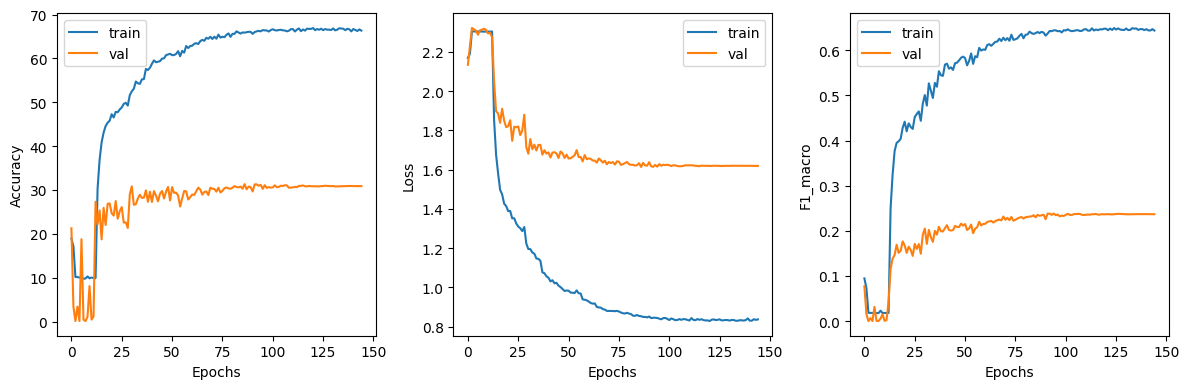

In [78]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

axes[0].plot(training_history['accuracy'], label='train')
axes[0].plot(validation_history['accuracy'], label='val')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(training_history['loss'], label='train')
axes[1].plot(validation_history['loss'], label='val')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

axes[2].plot(training_history['f1_macro'], label='train')
axes[2].plot(validation_history['f1_macro'], label='val')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('F1_macro')
axes[2].legend()

fig.tight_layout()
plt.show()

In [79]:
torch.save(model.state_dict(), "modello.pth")

In [80]:
criterion = nn.CrossEntropyLoss() # same criterion used while training
metrics = {"accuracy": Accuracy(), "loss": Loss(criterion), "f1_macro": Fbeta(beta=1.0, average=True, device=device)}

In [81]:
def evaluate_model(evaluator, test_loader):
    state = evaluator.run(test_loader)
    metrics = evaluator.state.metrics
    test_loss = metrics['loss']
    test_acc = metrics['accuracy']
    test_f1 = metrics['f1_macro']
    return test_loss, test_acc, test_f1

In [83]:
best_model = NNClassifier(input_size, hidden_size1, hidden_size2, hidden_size3, hidden_size4, output_size)
best_model.load_state_dict(torch.load('models/best_EARLY_model_145.pt'))
best_model.to(device)

NNClassifier(
  (input_layer): Linear(in_features=58, out_features=512, bias=True)
  (hidden_layer1): Linear(in_features=512, out_features=256, bias=True)
  (hidden_layer2): Linear(in_features=256, out_features=128, bias=True)
  (hidden_layer3): Linear(in_features=128, out_features=128, bias=True)
  (output_layer): Linear(in_features=128, out_features=10, bias=True)
  (tanh): ReLU()
  (dropout): Dropout(p=0.4, inplace=False)
)

In [84]:
NOREG_evaluator = create_supervised_evaluator(best_model, metrics=metrics, device=device)
loss_ES, acc_ES, f1_ES = evaluate_model(NOREG_evaluator, test_loader)
print("Model with scheduler, pesi e architettura maggiore - Loss: {:.4f}, Accuracy: {:.4f}, F1: {:.4f}".format(loss_ES, acc_ES, f1_ES))

Model with scheduler, pesi e architettura maggiore - Loss: 1.6162, Accuracy: 0.3081, F1: 0.2353


In [85]:
from sklearn.metrics import classification_report

In [86]:
model.to(device)

y_true, y_pred = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        predicted = torch.argmax(outputs, dim=1)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [87]:
print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.1139    0.1406    0.1259        64
           1     0.1382    0.1562    0.1467       192
           2     0.0825    0.2248    0.1207       516
           3     0.1492    0.4286    0.2214      1512
           4     0.2268    0.2608    0.2426      3769
           5     0.3799    0.2527    0.3035      8246
           6     0.4922    0.2084    0.2928     13559
           7     0.4979    0.3854    0.4345     11998
           8     0.1723    0.5710    0.2647      3583
           9     0.1407    0.3449    0.1999       461

    accuracy                         0.3081     43900
   macro avg     0.2394    0.2974    0.2353     43900
weighted avg     0.4013    0.3081    0.3206     43900

